In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import sys
sys.path.append("D:\Vlad\ds_for_terramechanica\source")
from utils.data_preprocessing import create_dataset
from sklearn.metrics.pairwise import euclidean_distances
import GPy

from models.bmgp import AR1

 C:\Users\fedi_vl\AppData\Roaming\Python\Python39\site-packages\gpflow\experimental\utils.py:42: UserWarning:You're calling gpflow.experimental.check_shapes.decorator.check_shapes which is considered *experimental*. Expect: breaking changes, poor documentation, and bugs.
 C:\Users\fedi_vl\AppData\Roaming\Python\Python39\site-packages\gpflow\experimental\utils.py:42: UserWarning:You're calling gpflow.experimental.check_shapes.inheritance.inherit_check_shapes which is considered *experimental*. Expect: breaking changes, poor documentation, and bugs.


Fortran code not compiled, module not functional


In [2]:
import gpflow
import mfgp.models as models
from mfgp.adaptation_maximizers import ScipyDirectMaximizer

In [21]:
tf.config.run_functions_eagerly(True)

In [22]:
def f_low(x):
    X = np.atleast_2d(x)
    return tf.sin(8*np.pi*X)

def f_medium(x):
    X = np.atleast_2d(x)
    return f_low(x) + 0.3*tf.sin(2*np.pi*X)

def f_high(x):
    # return f_low(x)**2
    X = np.atleast_2d(x)
    return f_low(x)*0.8 + 0.3*tf.sin(2*np.pi*X)
    # return f_medium(x)*0.8

 C:\Users\fedi_vl\AppData\Roaming\Python\Python39\site-packages\gpflow\experimental\utils.py:42: UserWarning:You're calling gpflow.experimental.check_shapes.checker.ShapeChecker.__init__ which is considered *experimental*. Expect: breaking changes, poor documentation, and bugs.


Error before optimsation tf.Tensor(0.05646151981206463, shape=(), dtype=float64)
Negative of likelihood before optimisation tf.Tensor([[13292285.73571419]], shape=(1, 1), dtype=float64)
negative of likelihood after optimisation tf.Tensor([[19.24421152]], shape=(1, 1), dtype=float64)
Error after optimsation tf.Tensor(0.0044509841621110805, shape=(), dtype=float64)


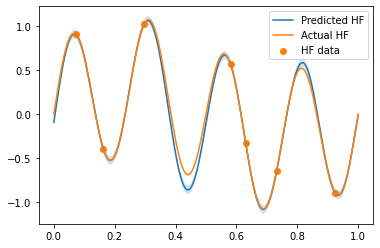

In [4]:
input_dim, num_low, num_medium, num_high = 1, 50, 15, 7
f_list = [None, None]
X_train_low = tf.random.uniform((num_low,input_dim), minval=0, maxval=1, dtype=tf.float64)
X_train_medium = tf.random.uniform((num_medium,input_dim), minval=0, maxval=1, dtype=tf.float64)
X_train_high = tf.random.uniform((num_high,input_dim), minval=0, maxval=1, dtype=tf.float64)
X_train = [X_train_low, X_train_high]
lower_bound, upper_bound = [0]*input_dim, [1]*input_dim
Y_train_low = f_low(X_train_low)
Y_train_medium = f_medium(X_train_medium)
Y_train_high = f_high(X_train_high)
num_test = 200
X_test = tf.cast(tf.reshape(tf.linspace(0, 1, num_test), (num_test, input_dim)), dtype=tf.float64)
Y_test_high = f_high(X_test)
Y_test_low = f_low(X_test)
model = AR1(input_dim, f_list, lower_bound, upper_bound)
model.set_training_data(X_train, [Y_train_low, Y_train_high])
model.fit()
mean, var = model.predict(X_test, level=-1)
print("Error before optimsation", tf.linalg.norm(mean - Y_test_high)/num_test)
# print("Trainable parameters before optimisation",model.trainable_parameters)
print("Negative of likelihood before optimisation", model.neg_unnormalised_log_likelihood())
model.ARD()
# print("Trainable parameters after optimisation",model.trainable_parameters)
print("negative of likelihood after optimisation", model.neg_unnormalised_log_likelihood())
mean, var = model.predict(X_test, level=-1)
print("Error after optimsation", tf.linalg.norm(mean - Y_test_high)/num_test)
# print(model.cholesky)
# TODO: ARD works well for 2 fidelities. Fails after that. 
# Putting bounds on each parameter based on fourier transformation will solve it. But, that is A LOT WORK :(
#model.adapt_one_level(3)
#model.ARD()
std = tf.sqrt(var)
plt.plot(X_test, mean, label='Predicted HF')
plt.plot(X_test, Y_test_high, label='Actual HF')

plt.fill_between(X_test[:, 0], (mean-std)[:, 0], (mean+std)[:, 0], alpha=0.2)
plt.scatter(model.X_train[-1], model.Y_train[-1], label='HF data')
# print(model.X_train[-1])
plt.legend()
plt.show()

In [5]:
#Kxstar_xstar = model.diag_kernel_list[1](X_test, X_test)
Kxstar = model.evaluate_Kxstar(X_test, 1)

In [6]:
X_test = np.array([[0.]])

In [7]:
rho = float(model.rho_kernel[1].rho.numpy())
lengthscale_hh_l = float(model.diag_kernel_list[1].kernels[0].kernels[2].lengthscales.numpy())
variance_hh_l = float(model.diag_kernel_list[1].kernels[0].kernels[2].variance.numpy())
lengthscale_delta = float(model.diag_kernel_list[1].kernels[1].lengthscales.numpy())
variance_delta = float(model.diag_kernel_list[1].kernels[1].variance.numpy())
lengthscale_ll = float(model.diag_kernel_list[0].lengthscales.numpy())
variance_ll= float(model.diag_kernel_list[0].variance.numpy())
n_predictions = X_test.shape[0]


K_l_hh = variance_hh_l*pd.DataFrame(np.exp(-0.5*(euclidean_distances( X_test, X_train_high.numpy())/lengthscale_hh_l)**2))
K_delta = variance_delta*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, X_train_high.numpy())/lengthscale_delta)**2))
K_hh = K_delta + (rho**2)*K_l_hh
K_ll = variance_ll*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, X_train_low.numpy())/lengthscale_ll)**2))
K_hl_right_up = rho*variance_ll*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, X_train_low.numpy())/lengthscale_ll)**2))
K_hl_left_down = rho*variance_ll*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, X_train_high.numpy())/lengthscale_ll)**2))

pred_kernel = np.zeros((n_predictions + n_predictions, num_high + num_low))
pred_kernel[:n_predictions, :num_low] = K_hl_right_up
pred_kernel[:n_predictions, num_low:] = K_hh
pred_kernel[n_predictions:, :num_low] = K_ll
pred_kernel[n_predictions:, num_low:] = K_hl_left_down
Y_predictions_ = np.matmul(pred_kernel,  model.scaled_Y_train.numpy())

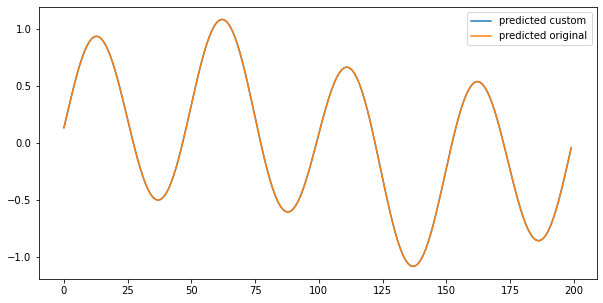

In [258]:
plt.figure(figsize=(10,5))
plt.plot(Y_predictions_[:200], label='predicted custom')
plt.plot(mean, label='predicted original')

plt.legend()

In [201]:
posterior_mean = np.matmul(Kxstar.numpy(), model.scaled_Y_train.numpy())

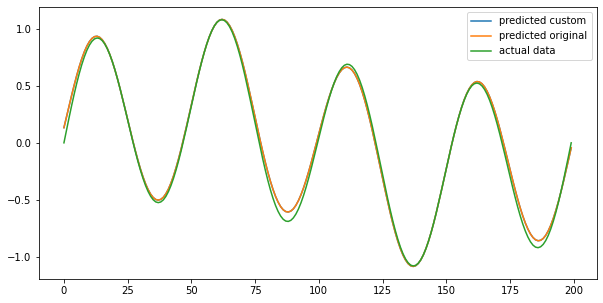

In [202]:
plt.figure(figsize=(10,5))
plt.plot(posterior_mean, label='predicted custom')
plt.plot(mean, label='predicted original')
plt.plot(Y_test_high, label='actual data')
plt.legend()

Train AR1 on terramechanical data

In [4]:
flat_runs = np.array([4322,4321,4323,4329,4328,4325,4330,4331,4332,4334,4335,4333,4336,4337,4338,4340,4341,4339,4343,4342,4345,4347,4348,4346,4350,4349,
                      4351,4354,4353,4352,4355,4356,4357,4359,4360,4366,4361,4363,4362,4364,4365,4367,4368,4369,4370,4374,4373,4372,4371,4375,4376,4377,
                      4378,4379,4380,4381,4382,4383,4384,4385,4386,4390,4389,4388,4387]) # 4303,4305,4318,4319,4320 
# 1/5 go to the train
train_share = 0.33
train_flat = np.random.choice(range(len(flat_runs)), size=round(len(flat_runs)*train_share), replace=False) 
#train_bump = np.random.choice(range(len(bump_runs)), size=2, replace=False)
train = flat_runs[train_flat]
test = flat_runs[[x for x in range(len(flat_runs)) if x not in train_flat]]

troll_force, scm_force, scm_X, terra_force = create_dataset(train, 1)
troll_force_more_points, scm_force_more_points, scm_X_more_points, terra_force_more_points = create_dataset(train, 7)

scm_X = np.concatenate(scm_X)
scm_force = np.concatenate(scm_force)
#troll_X = np.concatenate(troll_X)
troll_force = np.concatenate(troll_force)


scm_X_more_points = np.concatenate(scm_X_more_points)
scm_force_more_points = np.concatenate(scm_force_more_points)
#troll_X = np.concatenate(troll_X)
troll_force_more_points = np.concatenate(troll_force_more_points)

troll_force_test, scm_force_test, scm_X_test, terra_force_test = create_dataset(test, 10)

100%|██████████████████████████████████████████████████ [28:28]| 44/44 [28:28<00:00, 38.83s/it]


In [272]:
scm_X.shape

(365, 12)

In [273]:
scm_X_more_points.shape

(2681, 12)

In [274]:
pd.DataFrame(scm_X).to_csv("X_hf_train_AR1.csv", header = False, index = False, sep="\t")
pd.DataFrame(scm_X_more_points).to_csv("X_lf_train_AR1.csv", header = False, index = False, sep="\t")

In [275]:
input_dim = 12
lower_bound, upper_bound = np.min(np.concatenate([np.min(scm_X, axis=0)[None], np.min(scm_X_more_points, axis=0)[None]], axis=0), axis=0), np.max(np.concatenate([np.max(scm_X, axis=0)[None], np.max(scm_X_more_points, axis=0)[None]], axis=0), axis=0)
f_list = [None, None]
X_train = [tf.convert_to_tensor(scm_X_more_points), tf.convert_to_tensor(scm_X)]
test_id = 5

model = AR1(input_dim, f_list, lower_bound, upper_bound)
model.set_training_data(X_train, [tf.convert_to_tensor(scm_force_more_points[:, 0][:, None]), tf.convert_to_tensor(troll_force[:, 0][:, None])])
model.fit()
mean, var = model.predict(tf.convert_to_tensor(scm_X_test[test_id]), level=-1)
print("Error before optimsation", tf.linalg.norm(mean - tf.convert_to_tensor(troll_force_test[test_id][:, 0][:, None]))/troll_force_test[test_id].shape[0])
print("Negative of likelihood before optimisation", model.neg_unnormalised_log_likelihood())
model.ARD()
print("negative of likelihood after optimisation", model.neg_unnormalised_log_likelihood())
mean, var = model.predict(tf.convert_to_tensor(scm_X_test[test_id]), level=-1)
print("Error after optimsation", tf.linalg.norm(mean - tf.convert_to_tensor(troll_force_test[test_id][:, 0][:, None]))/troll_force_test[test_id].shape[0])

#model.adapt_one_level(3)
#model.ARD()

lf_mean, lf_var = model.predict(tf.convert_to_tensor(scm_X_test[test_id]), level=0)

Error before optimsation tf.Tensor(0.21067635136877577, shape=(), dtype=float64)
Negative of likelihood before optimisation tf.Tensor([[4.94162805e+09]], shape=(1, 1), dtype=float64)
negative of likelihood after optimisation tf.Tensor([[141795.49710634]], shape=(1, 1), dtype=float64)
Error after optimsation tf.Tensor(0.4907285869637439, shape=(), dtype=float64)


In [298]:
pd.DataFrame(model.scaled_Y_train.numpy()).to_csv("ar1_scaled_y_train.csv", header = False, index = False, sep="\t")

In [366]:
X_test = scm_X_test[test_id]

In [367]:
rho = float(model.rho_kernel[1].rho.numpy())
lengthscale_hh_l = float(model.diag_kernel_list[1].kernels[0].kernels[2].lengthscales.numpy())
variance_hh_l = float(model.diag_kernel_list[1].kernels[0].kernels[2].variance.numpy())
lengthscale_delta = float(model.diag_kernel_list[1].kernels[1].lengthscales.numpy())
variance_delta = float(model.diag_kernel_list[1].kernels[1].variance.numpy())
lengthscale_ll = float(model.diag_kernel_list[0].lengthscales.numpy())
variance_ll= float(model.diag_kernel_list[0].variance.numpy())
n_predictions = X_test.shape[0]
num_high = scm_X.shape[0]
num_low = scm_X_more_points.shape[0]


K_l_hh = variance_hh_l*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, scm_X)/lengthscale_hh_l)**2))
K_delta = variance_delta*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, scm_X)/lengthscale_delta)**2))
K_hh = K_delta + (rho**2)*K_l_hh
K_ll = variance_ll*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, scm_X_more_points)/lengthscale_ll)**2))
K_hl_right_up = rho*variance_ll*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, scm_X_more_points)/lengthscale_ll)**2))
K_hl_left_down = rho*variance_ll*pd.DataFrame(np.exp(-0.5*(euclidean_distances(X_test, scm_X)/lengthscale_ll)**2))

pred_kernel = np.zeros((n_predictions + n_predictions, num_high + num_low))
pred_kernel[:n_predictions, :num_low] = K_hl_right_up
pred_kernel[:n_predictions, num_low:] = K_hh

pred_kernel[n_predictions:, :num_low] = K_ll
pred_kernel[n_predictions:, num_low:] = K_hl_left_down
Y_predictions_ = np.matmul(pred_kernel,  model.scaled_Y_train.numpy())

In [368]:
Y_predictions_

array([[-2.39463639e+00],
       [-1.10890143e+00],
       [-1.78361582e+00],
       [-1.58614690e+00],
       [ 1.64349731e-01],
       [-1.84801620e+00],
       [-2.76830408e+00],
       [-1.96909623e+00],
       [ 7.77061207e-03],
       [ 3.49260702e-01],
       [-8.29818351e-01],
       [ 9.22164455e-02],
       [-2.66019001e+00],
       [ 2.72959669e-01],
       [-4.88477455e+00],
       [-5.06722641e+00],
       [ 2.38412984e-01],
       [-3.92055031e+00],
       [-3.27613321e+00],
       [-5.63446352e+00],
       [-2.32059971e+00],
       [-3.47301631e+00],
       [-3.23445848e+00],
       [-1.53918315e+00],
       [-2.13738339e-01],
       [-8.60974559e-01],
       [-8.44845819e-02],
       [-1.10233486e+00],
       [-4.14238265e-01],
       [-2.43750754e-01],
       [-1.00021394e+00],
       [-2.93548516e-01],
       [-1.07978064e-01],
       [-2.88253210e-01],
       [-2.49989422e+00],
       [-2.86081302e+00],
       [-2.55689665e-01],
       [-7.80589759e-01],
       [-6.8

In [299]:
pd.DataFrame(scm_X_test[test_id]).to_csv("test.csv", header = False, index = False, sep="\t")

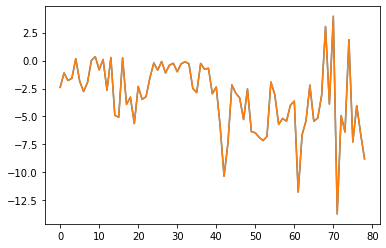

In [355]:
plt.plot(model.predict(tf.convert_to_tensor(scm_X_test[test_id]), level=-1)[0])
plt.plot(Y_predictions_[:79])

In [283]:
Y_predictions_.shape

(158, 1)

negative of likelihood after optimisation tf.Tensor([[141441.48864457]], shape=(1, 1), dtype=float64)


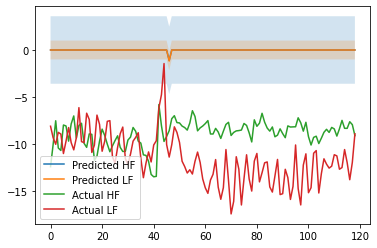

negative of likelihood after optimisation tf.Tensor([[141439.75778336]], shape=(1, 1), dtype=float64)


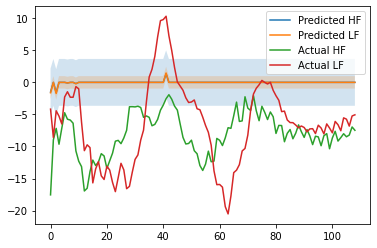

negative of likelihood after optimisation tf.Tensor([[141439.75932278]], shape=(1, 1), dtype=float64)


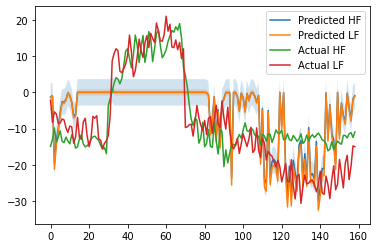

negative of likelihood after optimisation tf.Tensor([[141220.71581863]], shape=(1, 1), dtype=float64)


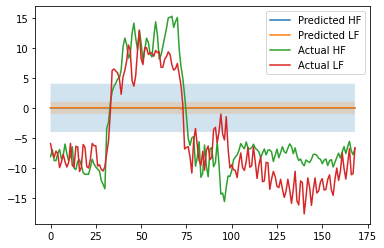

negative of likelihood after optimisation tf.Tensor([[141220.71564618]], shape=(1, 1), dtype=float64)


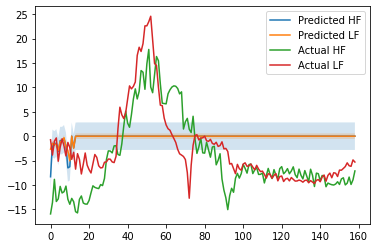

negative of likelihood after optimisation tf.Tensor([[141220.71564618]], shape=(1, 1), dtype=float64)


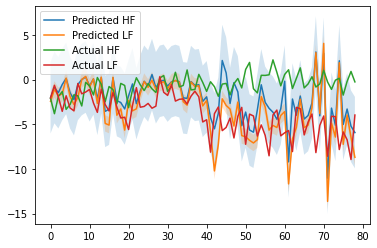

negative of likelihood after optimisation tf.Tensor([[141220.71564618]], shape=(1, 1), dtype=float64)


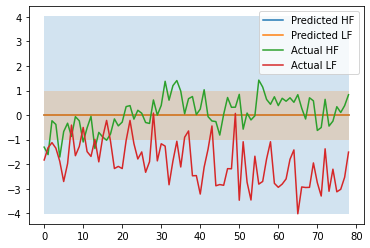

negative of likelihood after optimisation tf.Tensor([[141220.71564618]], shape=(1, 1), dtype=float64)


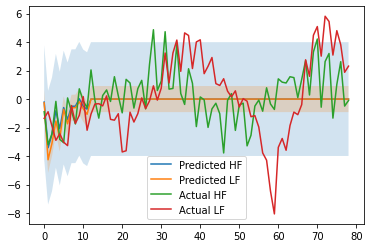

negative of likelihood after optimisation tf.Tensor([[141220.71564618]], shape=(1, 1), dtype=float64)


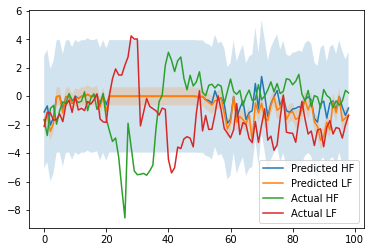

negative of likelihood after optimisation tf.Tensor([[141220.71564618]], shape=(1, 1), dtype=float64)


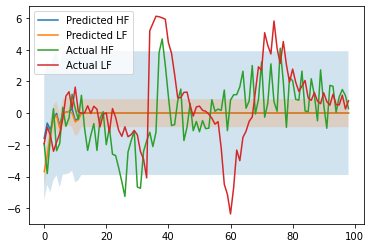

In [8]:
for test_id in range(10):
    model.ARD()
    print("negative of likelihood after optimisation", model.neg_unnormalised_log_likelihood())
    mean, var = model.predict(tf.convert_to_tensor(scm_X_test[test_id]), level=-1)
    lf_mean, lf_var = model.predict(tf.convert_to_tensor(scm_X_test[test_id]), level=0)

    std = tf.sqrt(var)
    plt.plot(mean, label='Predicted HF')
    plt.plot(lf_mean, label='Predicted LF')
    plt.plot(troll_force_test[test_id][:, 0][:, None], label='Actual HF')
    plt.plot(scm_force_test[test_id][:, 0][:, None], label='Actual LF')
    plt.fill_between(range(len((mean-std)[:, 0])), (mean-std)[:, 0], (mean+std)[:, 0], alpha=0.2)
    plt.fill_between(range(len((lf_mean-lf_var)[:, 0])), (lf_mean-lf_var)[:, 0], (lf_mean+lf_var)[:, 0], alpha=0.2)


    plt.legend()
    plt.show()

In [119]:
model

name,class,transform,prior,trainable,shape,dtype,value
AR1.offdiag_kernel_list[0][0].kernels[0].variance AR1.delta_kernel[0].variance AR1.diag_kernel_list[0].variance AR1.diag_kernel_list[1].kernels[0].kernels[2].variance,Parameter,Softplus,,False,(),float64,1
AR1.offdiag_kernel_list[0][0].kernels[0].lengthscales AR1.delta_kernel[0].lengthscales AR1.diag_kernel_list[0].lengthscales AR1.diag_kernel_list[1].kernels[0].kernels[2].lengthscales,Parameter,Softplus,,True,(),float64,2e-05
AR1.offdiag_kernel_list[0][0].kernels[1].rho AR1.rho_kernel[1].rho AR1.diag_kernel_list[1].kernels[0].kernels[0].rho AR1.diag_kernel_list[1].kernels[0].kernels[1].rho,Parameter,Softplus,,True,(),float64,0.6131
AR1.delta_kernel[1].variance AR1.diag_kernel_list[1].kernels[1].variance,Parameter,Softplus,,True,(),float64,25.6933
AR1.delta_kernel[1].lengthscales AR1.diag_kernel_list[1].kernels[1].lengthscales,Parameter,Softplus,,True,(),float64,0.07585


GPDFC

In [4]:
flat_runs = np.array([4322,4321,4323,4329,4328,4325,4330,4331,4332,4334,4335,4333,4336,4337,4338,4340,4341,4339,4343,4342,4345,4347,4348,4346,4350,4349,
                      4351,4354,4353,4352,4355,4356,4357,4359,4360,4366,4361,4363,4362,4364,4365,4367,4368,4369,4370,4374,4373,4372,4371,4375,4376,4377,
                      4378,4379,4380,4381,4382,4383,4384,4385,4386,4390,4389,4388,4387]) # 4303,4305,4318,4319,4320 
# 1/3 go to the train
train_share = 0.33
train_flat = np.random.choice(range(len(flat_runs)), size=round(len(flat_runs)*train_share), replace=False) 
#train_bump = np.random.choice(range(len(bump_runs)), size=2, replace=False)
train = flat_runs[train_flat]
test = flat_runs[[x for x in range(len(flat_runs)) if x not in train_flat]]

troll_force, scm_force, scm_X, terra_force = create_dataset(train, 1)

scm_X = np.concatenate(scm_X)
scm_force = np.concatenate(scm_force)
#troll_X = np.concatenate(troll_X)
troll_force = np.concatenate(troll_force)

troll_force_test, scm_force_test, scm_X_test, terra_force_test = create_dataset(test, 10)

100%|██████████████████████████████████████████████████ [29:23]| 44/44 [29:23<00:00, 40.08s/it]


In [6]:
train_share = 1
train_flat = np.random.choice(range(len(flat_runs)), size=round(len(flat_runs)*train_share), replace=False) 
#train_bump = np.random.choice(range(len(bump_runs)), size=2, replace=False)
train = flat_runs[train_flat]
test = flat_runs[[x for x in range(len(flat_runs)) if x not in train_flat]]

troll_force_more_points, scm_force_more_points, scm_X_more_points, terra_force_more_points = create_dataset(train, 5)

scm_X_more_points = np.concatenate(scm_X_more_points)
scm_force_more_points = np.concatenate(scm_force_more_points)
#troll_X = np.concatenate(troll_X)
troll_force_more_points = np.concatenate(troll_force_more_points)

100%|██████████████████████████████████████████████████ [43:39]| 65/65 [43:39<00:00, 40.30s/it]


In [9]:
input_dim = 12
lower_bound, upper_bound = np.min(np.concatenate([np.min(scm_X, axis=0)[None], np.min(scm_X_more_points, axis=0)[None]], axis=0), axis=0), np.max(np.concatenate([np.max(scm_X, axis=0)[None], np.max(scm_X_more_points, axis=0)[None]], axis=0), axis=0)
#f_list = [f_low, f_high]
X_train = [tf.convert_to_tensor(scm_X_more_points), tf.convert_to_tensor(scm_X)]

Create a train\test dataset

Build a surrogate GP on lower-fidelity and put it 

create a dataset for a surrogate

######################################################################################
SURROGAT MODEL NUMBER 0


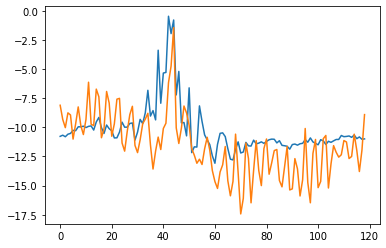

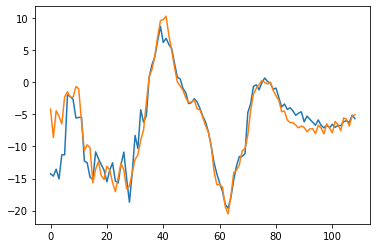

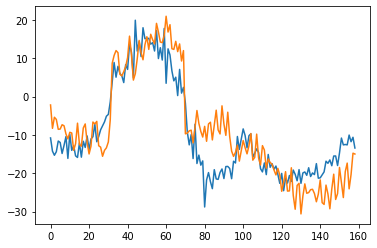

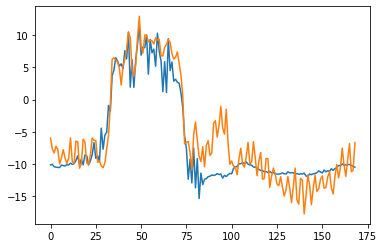

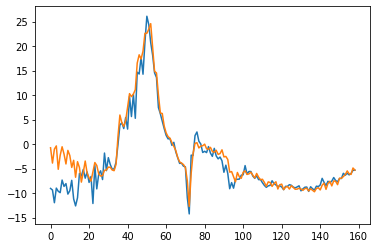

In [10]:
list_of_surrogates = []

input_dim = 12
i = 0 # only for the traction force

k1 = GPy.kern.RBF(input_dim)
gp_surrogate = GPy.models.GPRegression(X=scm_X_more_points, Y=scm_force_more_points[:, i][:, None], kernel=k1)
#gp_high[".*Gaussian_noise"] = gp_high.Y.var()*0.0001 # this could be derived from the high-frequencies forces after filtering (gp_high.Y.var = ...?)
#gp_medium[".*Gaussian_noise"].fix() # don't wtf is it
gp_surrogate.optimize(max_iters = 500)
#gp_surrogate.optimize_restarts(5, optimizer = "bfgs",  max_iters = 1000)
list_of_surrogates.append(gp_surrogate)
print("######################################################################################")
print("SURROGAT MODEL NUMBER " + str(i))
for j in range(5):
    plt.plot(gp_surrogate.predict(scm_X_test[j])[0])
    plt.plot(scm_force_test[j][:, i])
    plt.show()

In [21]:
def lf_gp_sur(X):
    return gp_surrogate.predict(X)[0]

In [22]:
gpdfc = models.GPDFC(input_dim, 1.0, 1, None, lf_gp_sur, lower_bound, upper_bound)
gpdfc.fit_with_val(scm_X, troll_force[:, 0][:, None])

13
[[[ 6.79741206e+00]
  [ 2.35115347e-36]
  [-1.03990449e-35]
  ...
  [ 2.35115347e-36]
  [ 2.24306074e-20]
  [ 2.33119351e-36]]

 [[ 4.56533081e+00]
  [ 1.57910000e-36]
  [ 1.55019539e-36]
  ...
  [ 1.57910000e-36]
  [ 3.09581578e-20]
  [ 1.57429631e-36]]

 [[ 4.94380576e+00]
  [ 1.71001051e-36]
  [ 1.74282026e-36]
  ...
  [ 1.71001051e-36]
  [ 5.89663768e-20]
  [ 1.70195742e-36]]

 ...

 [[ 1.36037525e+01]
  [ 4.70539515e-36]
  [ 1.36654325e-34]
  ...
  [ 4.70539515e-36]
  [-3.20100582e-35]
  [ 1.99903258e-35]]

 [[ 1.42619311e+01]
  [ 4.93305222e-36]
  [ 1.31247454e-34]
  ...
  [ 4.93305222e-36]
  [-3.16686356e-35]
  [ 2.05318859e-35]]

 [[ 1.33413532e+01]
  [ 4.61463399e-36]
  [ 1.35012195e-34]
  ...
  [ 4.61463399e-36]
  [-3.21299899e-35]
  [ 1.99486657e-35]]]


13
[[[-1.07721959e+01]
  [-3.72598947e-36]
  [-1.00418086e-35]
  ...
  [-3.72598947e-36]
  [ 4.33271809e-35]
  [ 4.15418856e-35]]

 [[-1.06734175e+01]
  [-3.69182305e-36]
  [-9.49671713e-36]
  ...
  [-3.69182305e-36]
  [ 4.35411956e-35]
  [ 4.19931679e-35]]

 [[-1.08049606e+01]
  [-3.73732244e-36]
  [-1.08569368e-35]
  ...
  [-3.73732244e-36]
  [ 4.37723413e-35]
  [ 4.11323527e-35]]

 ...

 [[-1.08227089e+01]
  [-3.74346139e-36]
  [-8.82634219e-36]
  ...
  [-3.74346139e-36]
  [ 4.49770329e-35]
  [ 4.19000265e-35]]

 [[-1.10244223e+01]
  [-3.81323194e-36]
  [-1.06235514e-35]
  ...
  [-3.81323194e-36]
  [ 4.48256993e-35]
  [ 4.10677457e-35]]

 [[-1.09905876e+01]
  [-3.80152886e-36]
  [-9.84682879e-36]
  ...
  [-3.80152886e-36]
  [ 4.47550920e-35]
  [ 4.13871334e-35]]]


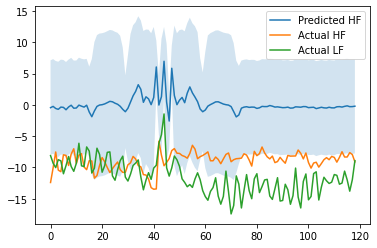

13
[[[-1.42611707e+01]
  [-4.93278920e-36]
  [-3.56228631e-35]
  ...
  [-4.93278920e-36]
  [ 6.13016534e-19]
  [-4.90722918e-36]]

 [[-1.46294787e+01]
  [-5.06018308e-36]
  [-3.55098930e-35]
  ...
  [-5.06018308e-36]
  [ 6.05316104e-19]
  [-5.03457563e-36]]

 [[-1.35409700e+01]
  [-4.68367936e-36]
  [-3.53057265e-35]
  ...
  [-4.68367936e-36]
  [ 6.16500652e-19]
  [-4.65822534e-36]]

 ...

 [[-6.27158548e+00]
  [-2.16927557e-36]
  [-1.97211575e-35]
  ...
  [-2.16927557e-36]
  [ 3.37642557e-19]
  [-2.15864439e-36]]

 [[-5.11613543e+00]
  [-1.76961753e-36]
  [-1.92840829e-35]
  ...
  [-1.76961753e-36]
  [ 3.37748655e-19]
  [-1.75962620e-36]]

 [[-5.65413461e+00]
  [-1.95570580e-36]
  [-1.95134541e-35]
  ...
  [-1.95570580e-36]
  [ 3.38116273e-19]
  [-1.94528189e-36]]]


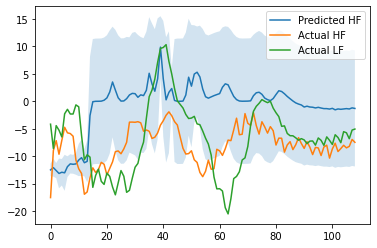

13
[[[-1.07718850e+01]
  [-3.72588191e-36]
  [-3.43228591e-35]
  ...
  [-3.72588191e-36]
  [ 6.11298046e-19]
  [-3.70102627e-36]]

 [[-1.42269379e+01]
  [-4.92094846e-36]
  [-3.55612278e-35]
  ...
  [-4.92094846e-36]
  [ 6.11776007e-19]
  [-4.89532508e-36]]

 [[-1.52913919e+01]
  [-5.28913191e-36]
  [-3.59993466e-35]
  ...
  [-5.28913191e-36]
  [ 6.15207841e-19]
  [-5.26325176e-36]]

 ...

 [[-1.17519678e+01]
  [-4.06488226e-36]
  [-3.46544524e-35]
  ...
  [-4.06488226e-36]
  [ 6.28819233e-19]
  [-4.04018101e-36]]

 [[-1.06036023e+01]
  [-3.66767472e-36]
  [-3.42250438e-35]
  ...
  [-3.66767472e-36]
  [ 6.24846230e-19]
  [-3.64312070e-36]]

 [[-1.34038497e+01]
  [-4.63625088e-36]
  [-3.51821576e-35]
  ...
  [-4.63625088e-36]
  [ 6.28867330e-19]
  [-4.61120059e-36]]]


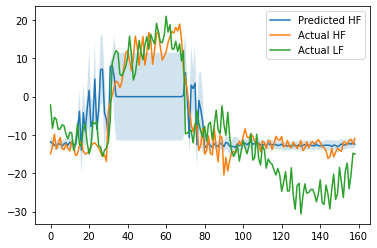

13
[[[-1.01172945e+01]
  [-3.49946594e-36]
  [-1.26488954e-35]
  ...
  [-3.49946594e-36]
  [ 4.32040036e-35]
  [ 4.19797837e-35]]

 [[-1.00298809e+01]
  [-3.46923050e-36]
  [-8.98017918e-36]
  ...
  [-3.46923050e-36]
  [ 4.35648799e-35]
  [ 4.33139907e-35]]

 [[-1.04074386e+01]
  [-3.59982373e-36]
  [-1.14819826e-35]
  ...
  [-3.59982373e-36]
  [ 4.36727088e-35]
  [ 4.18801885e-35]]

 ...

 [[-1.01986565e+01]
  [-3.52760821e-36]
  [-1.08933168e-35]
  ...
  [-3.52760821e-36]
  [ 4.50076491e-35]
  [ 4.24950220e-35]]

 [[-1.03476926e+01]
  [-3.57915824e-36]
  [-1.22845195e-35]
  ...
  [-3.57915824e-36]
  [ 4.48175146e-35]
  [ 4.17115313e-35]]

 [[-1.04622183e+01]
  [-3.61877147e-36]
  [-1.29158101e-35]
  ...
  [-3.61877147e-36]
  [ 4.46124602e-35]
  [ 4.12277968e-35]]]


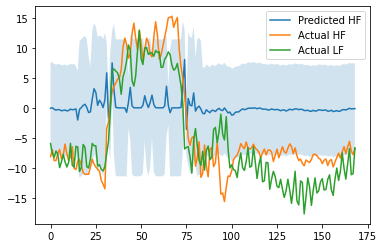

13
[[[-9.03438404e+00]
  [-3.12489859e-36]
  [-3.38183049e-35]
  ...
  [-3.12489859e-36]
  [ 6.16824592e-19]
  [-3.10068868e-36]]

 [[-9.35892392e+00]
  [-3.23715352e-36]
  [-3.38774803e-35]
  ...
  [-3.23715352e-36]
  [ 6.11548886e-19]
  [-3.21280523e-36]]

 [[-1.19513159e+01]
  [-4.13383469e-36]
  [-3.48010913e-35]
  ...
  [-4.13383469e-36]
  [ 6.16758919e-19]
  [-4.10898735e-36]]

 ...

 [[-5.98467615e+00]
  [-2.07003665e-36]
  [-1.96227708e-35]
  ...
  [-2.07003665e-36]
  [ 3.37087570e-19]
  [-2.05936441e-36]]

 [[-5.34177554e+00]
  [-1.84766408e-36]
  [-1.94000536e-35]
  ...
  [-1.84766408e-36]
  [ 3.35978872e-19]
  [-1.83705290e-36]]

 [[-5.31378275e+00]
  [-1.83798166e-36]
  [-1.93985335e-35]
  ...
  [-1.83798166e-36]
  [ 3.39109350e-19]
  [-1.82781242e-36]]]


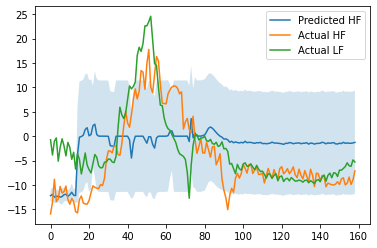

13
[[[-2.04230075e+00]
  [-7.06410389e-37]
  [-2.60059659e-35]
  ...
  [-7.06410389e-37]
  [ 4.10569466e-19]
  [-7.05257404e-37]]

 [[-2.13653922e+00]
  [-7.39006483e-37]
  [-2.60800746e-35]
  ...
  [-7.39006483e-37]
  [ 4.11308004e-19]
  [-7.37841873e-37]]

 [[-3.33088667e+00]
  [-1.15211873e-36]
  [-2.63071644e-35]
  ...
  [-1.15211873e-36]
  [ 4.09919554e-19]
  [-1.15036638e-36]]

 ...

 [[-6.73593596e+00]
  [-2.32988953e-36]
  [-2.72794445e-35]
  ...
  [-2.32988953e-36]
  [ 4.14677526e-19]
  [-2.32709806e-36]]

 [[-4.89513886e+00]
  [-1.69317714e-36]
  [-2.69204762e-35]
  ...
  [-1.69317714e-36]
  [ 4.20896125e-19]
  [-1.69122546e-36]]

 [[-5.76165988e+00]
  [-1.99289766e-36]
  [-2.71087339e-35]
  ...
  [-1.99289766e-36]
  [ 4.15391005e-19]
  [-1.99051546e-36]]]


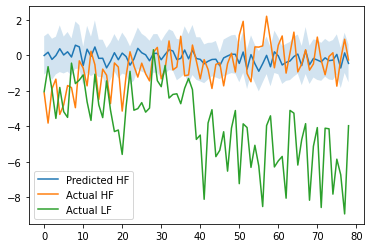

13
[[[-1.54279875e+00]
  [-5.33637891e-37]
  [ 3.14516303e-35]
  ...
  [-5.33637891e-37]
  [ 1.20004773e-34]
  [ 4.52019369e-35]]

 [[-1.91263738e+00]
  [-6.61561188e-37]
  [ 2.84980610e-35]
  ...
  [-6.61561188e-37]
  [ 1.19472884e-34]
  [ 4.39752355e-35]]

 [[-1.81360805e+00]
  [-6.27307983e-37]
  [ 3.01213651e-35]
  ...
  [-6.27307983e-37]
  [ 1.19734515e-34]
  [ 4.46055397e-35]]

 ...

 [[-2.06804692e+00]
  [-7.15315717e-37]
  [ 2.80961564e-35]
  ...
  [-7.15315717e-37]
  [ 1.22732072e-34]
  [ 4.41393576e-35]]

 [[-2.11314970e+00]
  [-7.30916296e-37]
  [ 2.78290911e-35]
  ...
  [-7.30916296e-37]
  [ 1.22886321e-34]
  [ 4.40549183e-35]]

 [[-2.15692569e+00]
  [-7.46057949e-37]
  [ 2.75167299e-35]
  ...
  [-7.46057949e-37]
  [ 1.22653298e-34]
  [ 4.39319738e-35]]]


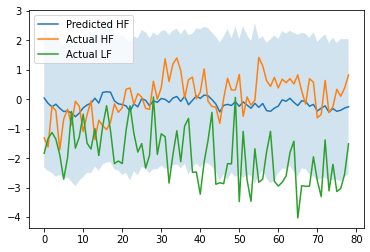

13
[[[-1.21664304e+00]
  [-4.20824053e-37]
  [-2.57313756e-35]
  ...
  [-4.20824053e-37]
  [ 4.10045025e-19]
  [-4.19972403e-37]]

 [[-2.17648314e+00]
  [-7.52822667e-37]
  [-2.60168535e-35]
  ...
  [-7.52822667e-37]
  [ 4.09509426e-19]
  [-7.51590513e-37]]

 [[-2.18667424e+00]
  [-7.56347663e-37]
  [-2.60900515e-35]
  ...
  [-7.56347663e-37]
  [ 4.12129185e-19]
  [-7.55139325e-37]]

 ...

 [[ 2.63969362e+00]
  [ 9.13042310e-37]
  [ 7.53898812e-37]
  ...
  [ 9.13042310e-37]
  [ 2.61032364e-20]
  [ 9.09096421e-37]]

 [[ 2.65183233e+00]
  [ 9.17240962e-37]
  [-2.06369541e-37]
  ...
  [ 9.17240962e-37]
  [ 3.22620400e-20]
  [ 9.13305206e-37]]

 [[ 2.62842196e+00]
  [ 9.09143559e-37]
  [-1.97803324e-36]
  ...
  [ 9.09143559e-37]
  [ 4.47751907e-20]
  [ 9.06017614e-37]]]


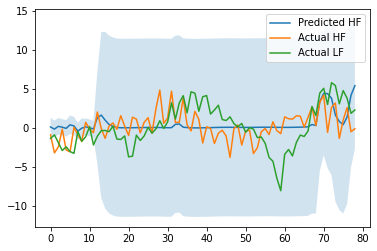

13
[[[-1.60086616e+00]
  [-5.53722797e-37]
  [ 3.09037098e-35]
  ...
  [-5.53722797e-37]
  [ 2.98643937e-35]
  [ 4.55304958e-35]]

 [[-1.62705561e+00]
  [-5.62781452e-37]
  [ 3.09595380e-35]
  ...
  [-5.62781452e-37]
  [ 2.98719712e-35]
  [ 4.54946168e-35]]

 [[-1.68874548e+00]
  [-5.84119332e-37]
  [ 3.10426899e-35]
  ...
  [-5.84119332e-37]
  [ 2.98632649e-35]
  [ 4.53074905e-35]]

 ...

 [[-2.17819448e+00]
  [-7.53414600e-37]
  [ 2.76082968e-35]
  ...
  [-7.53414600e-37]
  [ 3.05185926e-35]
  [ 4.42774334e-35]]

 [[-1.98753398e+00]
  [-6.87467137e-37]
  [ 2.86536705e-35]
  ...
  [-6.87467137e-37]
  [ 3.04354529e-35]
  [ 4.48161251e-35]]

 [[-2.19089843e+00]
  [-7.57808766e-37]
  [ 2.72396934e-35]
  ...
  [-7.57808766e-37]
  [ 3.03894513e-35]
  [ 4.40796132e-35]]]


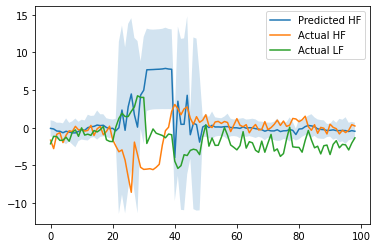

13
[[[-2.44844890e+00]
  [-8.46892769e-37]
  [-2.60910576e-35]
  ...
  [-8.46892769e-37]
  [ 4.09467598e-19]
  [-8.45526150e-37]]

 [[-2.55975289e+00]
  [-8.85391648e-37]
  [-2.61409760e-35]
  ...
  [-8.85391648e-37]
  [ 4.09861972e-19]
  [-8.83968877e-37]]

 [[-2.79277939e+00]
  [-9.65993069e-37]
  [-2.60827565e-35]
  ...
  [-9.65993070e-37]
  [ 4.09262805e-19]
  [-9.64364933e-37]]

 ...

 [[ 5.79632334e-01]
  [ 2.00488739e-37]
  [-1.51872685e-35]
  ...
  [ 2.00488739e-37]
  [ 2.16841591e-19]
  [ 1.98834676e-37]]

 [[ 3.75268544e-01]
  [ 1.29801449e-37]
  [-1.49696476e-35]
  ...
  [ 1.29801449e-37]
  [ 2.09965427e-19]
  [ 1.29009165e-37]]

 [[ 8.02101911e-01]
  [ 2.77438630e-37]
  [-1.52643091e-35]
  ...
  [ 2.77438630e-37]
  [ 2.22876541e-19]
  [ 2.74978435e-37]]]


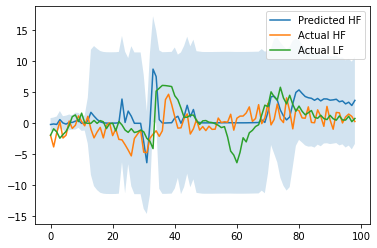

In [27]:
for test_id in range(10):
    mean, var = gpdfc.predict(tf.convert_to_tensor(scm_X_test[test_id]))

    std = tf.sqrt(var)
    plt.plot(mean, label='Predicted HF')
    plt.plot(troll_force_test[test_id][:, 0][:, None], label='Actual HF')
    plt.plot(scm_force_test[test_id][:, 0][:, None], label='Actual LF')
    plt.fill_between(range(len((mean-std)[:, 0])), (mean-std)[:, 0], (mean+std)[:, 0], alpha=0.2)


    plt.legend()
    plt.show()